In [1]:
import pandas as pd
import numpy as np

retail_df = pd.read_csv(
    "../../02_Cleaned_Data/online_retail_cleaned.csv"
)

retail_df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
retail_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      779425 non-null  int64  
 1   StockCode    779425 non-null  str    
 2   Description  779425 non-null  str    
 3   Quantity     779425 non-null  int64  
 4   InvoiceDate  779425 non-null  str    
 5   Price        779425 non-null  float64
 6   Customer ID  779425 non-null  float64
 7   Country      779425 non-null  str    
dtypes: float64(2), int64(2), str(4)
memory usage: 47.6 MB


In [3]:
retail_df["InvoiceDate"] = pd.to_datetime(
    retail_df["InvoiceDate"]
)

retail_df["Invoice_Month"] = retail_df["InvoiceDate"].dt.to_period("M")

retail_df[
    ["InvoiceDate", "Invoice_Month"]
].head()

,InvoiceDate,Invoice_Month
0,2009-12-01 07:45:00,2009-12
1,2009-12-01 07:45:00,2009-12
2,2009-12-01 07:45:00,2009-12
3,2009-12-01 07:45:00,2009-12
4,2009-12-01 07:45:00,2009-12


In [4]:
retail_df["Cohort_Month"] = retail_df.groupby(
    "Customer ID"
)["Invoice_Month"].transform("min")

retail_df[
    ["Customer ID","Invoice_Month","Cohort_Month"]
].head(10)

,Customer ID,Invoice_Month,Cohort_Month
0,13085.0,2009-12,2009-12
1,13085.0,2009-12,2009-12
2,13085.0,2009-12,2009-12
3,13085.0,2009-12,2009-12
4,13085.0,2009-12,2009-12
5,13085.0,2009-12,2009-12
6,13085.0,2009-12,2009-12
7,13085.0,2009-12,2009-12
8,13085.0,2009-12,2009-12
9,13085.0,2009-12,2009-12


In [5]:
invoice_year = retail_df["Invoice_Month"].dt.year
invoice_month = retail_df["Invoice_Month"].dt.month

cohort_year = retail_df["Cohort_Month"].dt.year
cohort_month = retail_df["Cohort_Month"].dt.month

years_diff = invoice_year - cohort_year
months_diff = invoice_month - cohort_month

retail_df["Cohort_Index"] = (
    years_diff * 12
    + months_diff
    + 1
)

retail_df[
    [
        "Customer ID",
        "Invoice_Month",
        "Cohort_Month",
        "Cohort_Index"
    ]
].head(10)

,Customer ID,Invoice_Month,Cohort_Month,Cohort_Index
0,13085.0,2009-12,2009-12,1
1,13085.0,2009-12,2009-12,1
2,13085.0,2009-12,2009-12,1
3,13085.0,2009-12,2009-12,1
4,13085.0,2009-12,2009-12,1
5,13085.0,2009-12,2009-12,1
6,13085.0,2009-12,2009-12,1
7,13085.0,2009-12,2009-12,1
8,13085.0,2009-12,2009-12,1
9,13085.0,2009-12,2009-12,1


In [6]:
cohort_data = retail_df.groupby(
    ["Cohort_Month", "Cohort_Index"]
)["Customer ID"].nunique().reset_index()

cohort_data.head(20)

,Cohort_Month,Cohort_Index,Customer ID
0,2009-12,1,955
1,2009-12,2,337
2,2009-12,3,319
3,2009-12,4,406
4,2009-12,5,363
5,2009-12,6,343
6,2009-12,7,360
7,2009-12,8,327
8,2009-12,9,321
9,2009-12,10,346


In [7]:
cohort_table = cohort_data.pivot(
    index="Cohort_Month",
    columns="Cohort_Index",
    values="Customer ID"
)

cohort_table.head()

Cohort_Index,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
Cohort_Month,,,,,,,,,,,,,,,,,,,,,
2009-12,955.0,337.0,319.0,406.0,363.0,343.0,360.0,327.0,321.0,346.0,...,289.0,251.0,289.0,270.0,248.0,244.0,301.0,291.0,389.0,188.0
2010-01,383.0,79.0,119.0,117.0,101.0,115.0,99.0,88.0,107.0,122.0,...,58.0,90.0,76.0,71.0,75.0,93.0,74.0,94.0,22.0,NaN
2010-02,374.0,89.0,84.0,109.0,92.0,75.0,72.0,107.0,95.0,103.0,...,75.0,60.0,61.0,54.0,86.0,86.0,61.0,22.0,NaN,NaN
2010-03,443.0,84.0,102.0,107.0,103.0,90.0,109.0,134.0,122.0,48.0,...,75.0,77.0,69.0,78.0,89.0,94.0,35.0,NaN,NaN,NaN
2010-04,294.0,57.0,57.0,48.0,54.0,66.0,81.0,77.0,31.0,32.0,...,46.0,41.0,44.0,53.0,66.0,17.0,NaN,NaN,NaN,NaN


In [8]:
cohort_size = cohort_table.iloc[:, 0]

retention_matrix = cohort_table.divide(
    cohort_size,
    axis=0
)

retention_matrix.head()

Cohort_Index,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
Cohort_Month,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.352880,0.334031,0.425131,0.380105,0.359162,0.376963,0.342408,0.336126,0.362304,...,0.302618,0.262827,0.302618,0.282723,0.259686,0.255497,0.315183,0.304712,0.407330,0.196859
2010-01,1.0,0.206266,0.310705,0.305483,0.263708,0.300261,0.258486,0.229765,0.279373,0.318538,...,0.151436,0.234987,0.198433,0.185379,0.195822,0.242820,0.193211,0.245431,0.057441,NaN
2010-02,1.0,0.237968,0.224599,0.291444,0.245989,0.200535,0.192513,0.286096,0.254011,0.275401,...,0.200535,0.160428,0.163102,0.144385,0.229947,0.229947,0.163102,0.058824,NaN,NaN
2010-03,1.0,0.189616,0.230248,0.241535,0.232506,0.203160,0.246050,0.302483,0.275395,0.108352,...,0.169300,0.173815,0.155756,0.176072,0.200903,0.212190,0.079007,NaN,NaN,NaN
2010-04,1.0,0.193878,0.193878,0.163265,0.183673,0.224490,0.275510,0.261905,0.105442,0.108844,...,0.156463,0.139456,0.149660,0.180272,0.224490,0.057823,NaN,NaN,NaN,NaN


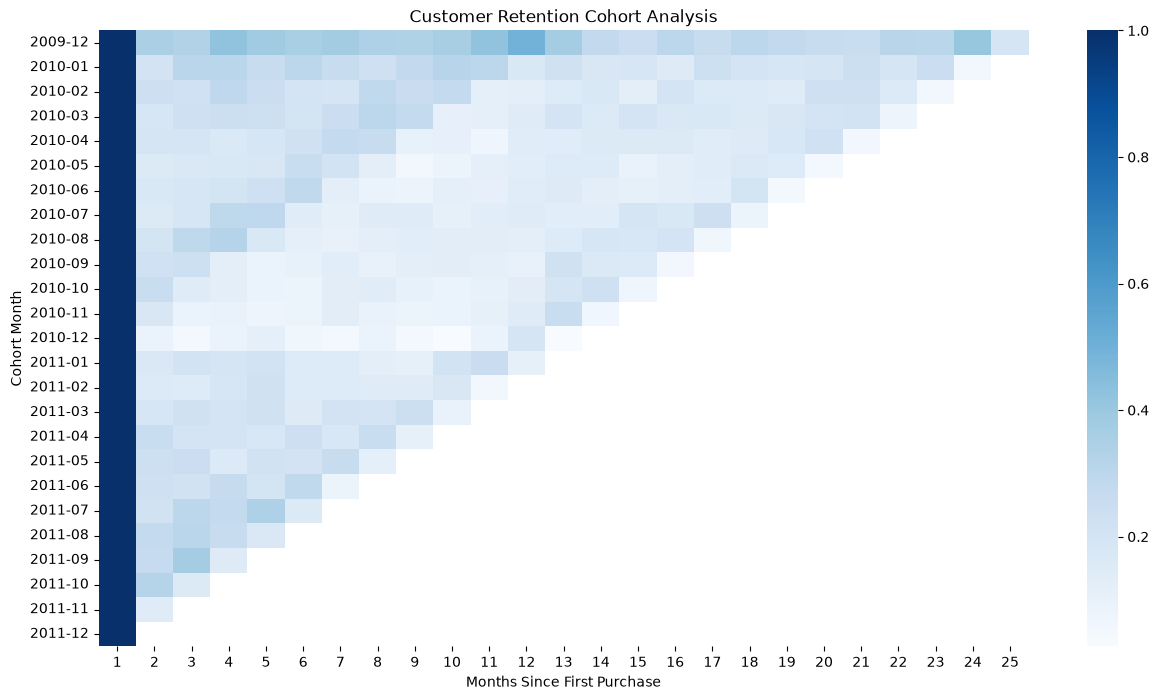

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,8))

sns.heatmap(
    retention_matrix,
    annot=False,
    cmap="Blues"
)

plt.title("Customer Retention Cohort Analysis")
plt.xlabel("Months Since First Purchase")
plt.ylabel("Cohort Month")

plt.show()

In [10]:
(retention_matrix * 100).round(2).head()

Cohort_Index,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
Cohort_Month,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,35.29,33.40,42.51,38.01,35.92,37.70,34.24,33.61,36.23,...,30.26,26.28,30.26,28.27,25.97,25.55,31.52,30.47,40.73,19.69
2010-01,100.0,20.63,31.07,30.55,26.37,30.03,25.85,22.98,27.94,31.85,...,15.14,23.50,19.84,18.54,19.58,24.28,19.32,24.54,5.74,NaN
2010-02,100.0,23.80,22.46,29.14,24.60,20.05,19.25,28.61,25.40,27.54,...,20.05,16.04,16.31,14.44,22.99,22.99,16.31,5.88,NaN,NaN
2010-03,100.0,18.96,23.02,24.15,23.25,20.32,24.60,30.25,27.54,10.84,...,16.93,17.38,15.58,17.61,20.09,21.22,7.90,NaN,NaN,NaN
2010-04,100.0,19.39,19.39,16.33,18.37,22.45,27.55,26.19,10.54,10.88,...,15.65,13.95,14.97,18.03,22.45,5.78,NaN,NaN,NaN,NaN


In [13]:
cohort_analysis = (retention_matrix * 100).round(2)

cohort_analysis.to_csv(
    "../../02_Cleaned_Data/cohort_analysis.csv"
)

print("Cohort Analysis CSV Exported Successfully")

Cohort Analysis CSV Exported Successfully


# Cohort Analysis Summary

## Objective
Analyze customer retention patterns over time using cohort analysis.

## Key Findings
- Most customers churn after the first few months.
- Retention stabilizes around 15–30% for many cohorts.
- December 2009 cohort showed stronger long-term retention.
- Early customer retention is the biggest business challenge.

## Business Recommendations
- Improve onboarding experience.
- Launch retention campaigns within first 90 days.
- Introduce loyalty and repeat purchase incentives.
- Track cohort performance monthly.